In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sys

sys.path.append("..")
import sourse
import os
import sourse_new
import matplotlib.patches as patches

plt.rcParams["font.size"] = 14

In [ ]:
7000 * sourse_new.dt

4.9898028160897695e-06

In [20]:
sim_ref = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
exp_ref = sourse_new.import_data(0, 0)[0]

sim_rough = -np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch200_depth20.csv")
sim_rough2 = -np.loadtxt(r"C:\Users\manat\project2\tmp_output\cupy_pitch200_depth20_5.csv")
sim_rough3 = -np.loadtxt(r"C:\Users\manat\project2\tmp_output\cupy_pitch200_depth20_6.csv")
exp_rough = sourse_new.import_data(125, 20)[0]

sim_ref = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_ref[9000:]), sourse_new.left, sourse_new.right)
exp_ref = sourse_new.kiritori2(exp_ref, sourse_new.left, sourse_new.right)

sim_rough = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough[9000:]), sourse_new.left, sourse_new.right)
sim_rough2 = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough2[9000:]), sourse_new.left, sourse_new.right)
sim_rough3 = sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_rough3[9000:]), sourse_new.left, sourse_new.right)
exp_rough = sourse_new.kiritori2(exp_rough, sourse_new.left, sourse_new.right)

yf_sim_ref, freq = sourse_new.make_fftdata(sim_ref, sourse_new.exp_dt)
yf_exp_ref, freq = sourse_new.make_fftdata(exp_ref, sourse_new.exp_dt)

yf_sim_rough, freq = sourse_new.make_fftdata(sim_rough, sourse_new.exp_dt)
yf_sim_rough2, freq = sourse_new.make_fftdata(sim_rough2, sourse_new.exp_dt)
yf_sim_rough3, freq = sourse_new.make_fftdata(sim_rough3, sourse_new.exp_dt)
yf_exp_rough, freq = sourse_new.make_fftdata(exp_rough, sourse_new.exp_dt)

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_50.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_51.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_52.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5

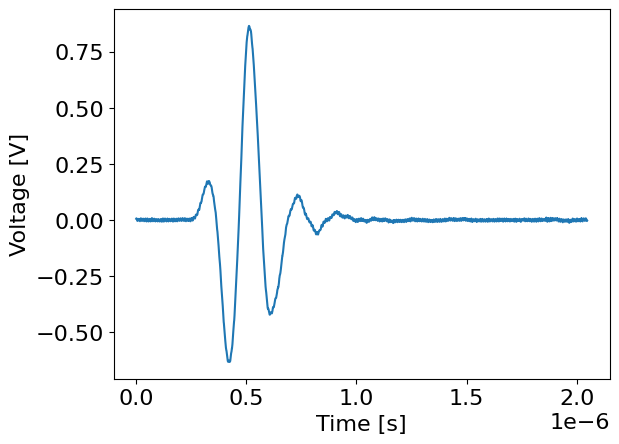

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt * len(exp_ref), sourse_new.exp_dt)
plt.plot(t, exp_ref)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.show()


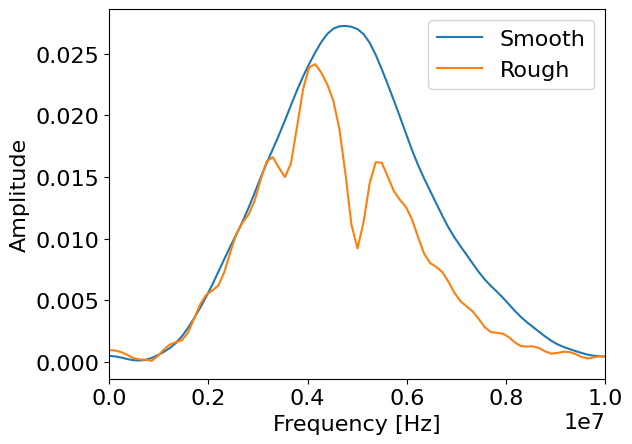

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
plt.plot(freq, yf_exp_ref, label="Smooth")
plt.plot(freq, yf_exp_rough, label="Rough")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.legend()
plt.xlim(0, 10e6)
plt.show()


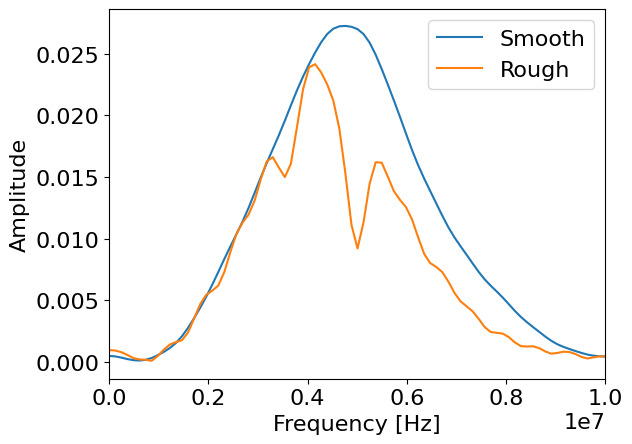

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
plt.plot(freq, yf_exp_ref, label="Smooth")
plt.plot(freq, yf_exp_rough, label="Rough")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.legend()
plt.xlim(0, 10e6)
plt.show()

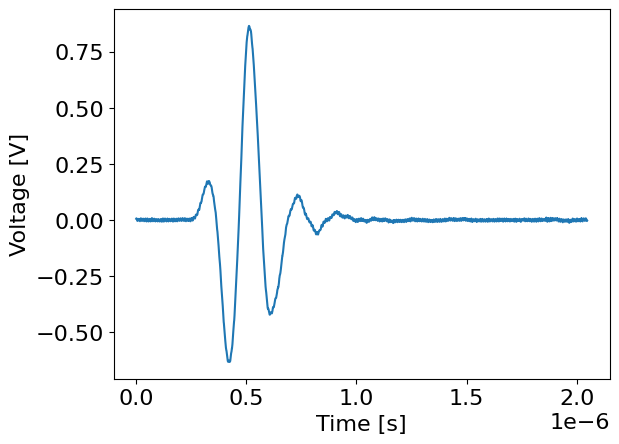

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)
plt.plot(t, exp_ref)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.show()


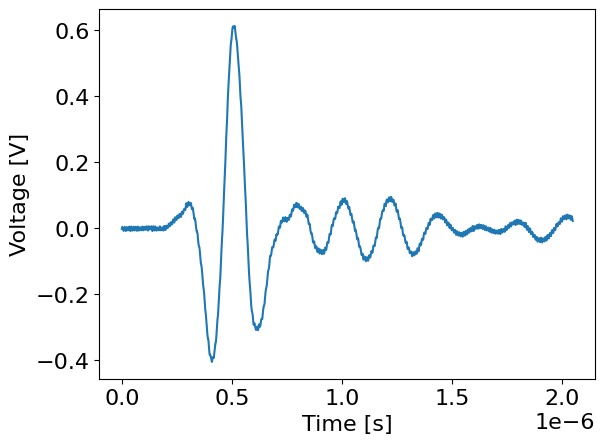

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)
plt.plot(t, exp_rough)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.show()

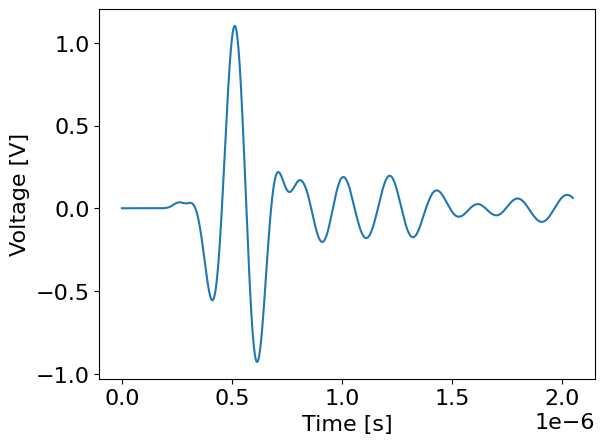

In [ ]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)
plt.plot(t, sim_rough)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.show()

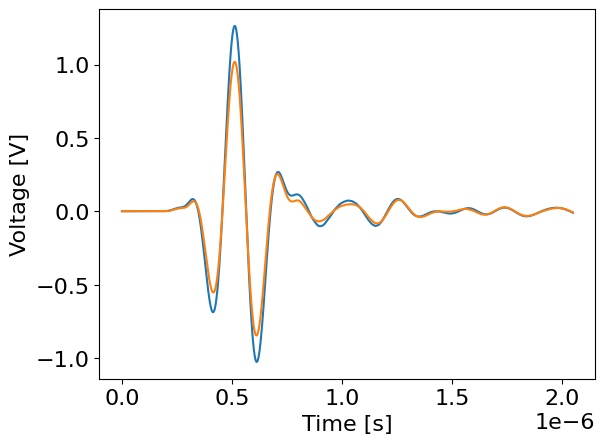

In [5]:
plt.rcParams["font.size"] = 16
plt.figure()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)
plt.plot(t, sim_rough)
plt.plot(t, sim_rough2)
plt.xlabel("Time [s]")
plt.ylabel("Voltage [V]")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


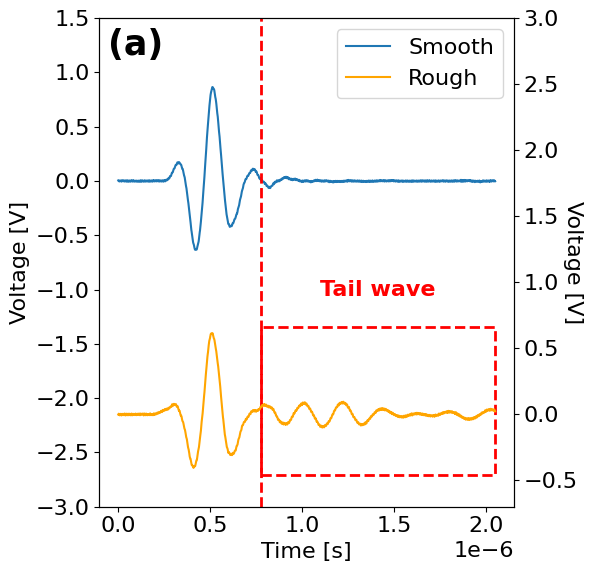

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)

(p1,) = ax.plot(t, exp_ref, label="Smooth")
(p2,) = twin1.plot(t, exp_rough, label="Rough", color="orange")
# 囲みたい範囲を指定（時間軸の範囲）
highlight_start = 1550 * sourse_new.exp_dt  # 開始時間
highlight_end = t[-1]

# 四角形を描画（twin1の軸に合わせる）
rect = patches.Rectangle(
    (highlight_start, twin1.get_ylim()[0]),
    highlight_end - highlight_start,
    twin1.get_ylim()[1] - twin1.get_ylim()[0],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
)
twin1.add_patch(rect)
# 四角形の上に文字を追加
# 左辺を上まで延長する縦線
ax.axvline(x=highlight_start, ymin=0, ymax=1, color="red", linestyle="--", linewidth=2)

text_x = (highlight_start + highlight_end) / 2  # 四角形の中央
text_y = twin1.get_ylim()[1] + 0.2  # 四角形の上端より少し上
twin1.text(text_x, text_y, "Tail wave", ha="center", va="bottom", fontsize=16, color="red", weight="bold")
# 左上に (a) を追加
ax.text(0.02, 0.98, "(a)", transform=ax.transAxes, fontsize=25, weight="bold", ha="left", va="top")
fig.tight_layout()
ax.set_ylim(-3.0, 1.5)
twin1.set_ylim(-0.7, 3)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Voltage [V]")
twin1.set_ylabel("Voltage [V]", rotation=270)
# step4 凡例の追加
ax.legend(handles=[p1, p2], fontsize=16)
plt.tight_layout()


plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure6a.eps", format="eps", dpi=300)
plt.show()


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


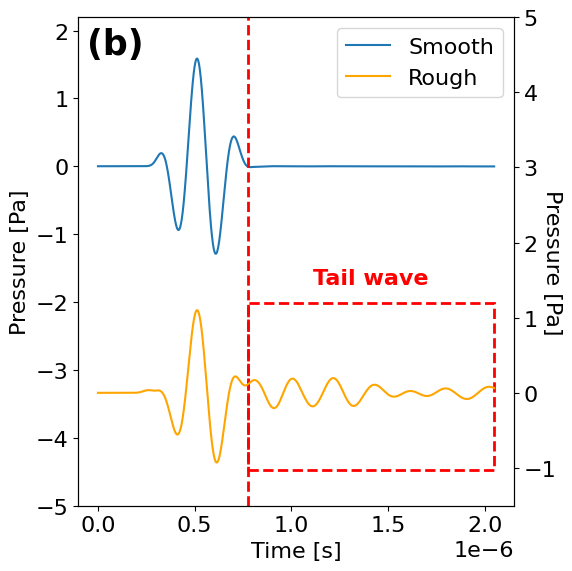

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
# step2 y軸の作成
twin1 = ax.twinx()
t = np.arange(0, sourse_new.exp_dt * len(sim_ref), sourse_new.exp_dt)

(p1,) = ax.plot(t, sim_ref, label="Smooth")
(p2,) = twin1.plot(t, sim_rough, label="Rough", color="orange")

# 囲みたい範囲を指定（時間軸の範囲）
highlight_start = 1550 * sourse_new.exp_dt  # 開始時間
highlight_end = t[-1]  # 終了時間

# 四角形を描画（twin1の軸に合わせる）
rect = patches.Rectangle(
    (highlight_start, twin1.get_ylim()[0]),
    highlight_end - highlight_start,
    twin1.get_ylim()[1] - twin1.get_ylim()[0],
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    linestyle="--",
)
twin1.add_patch(rect)
# 四角形の上に文字を追加
# 左辺を上まで延長する縦線
ax.axvline(x=highlight_start, ymin=0, ymax=1, color="red", linestyle="--", linewidth=2)

# 四角形の上に文字を追加
text_x = (highlight_start + highlight_end) / 2  # 四角形の中央
text_y = twin1.get_ylim()[1] + 0.2  # 四角形の上端より少し上
twin1.text(text_x, text_y, "Tail wave", ha="center", va="bottom", fontsize=16, color="red", weight="bold")
# 左上に (a) を追加
ax.text(0.02, 0.98, "(b)", transform=ax.transAxes, fontsize=25, weight="bold", ha="left", va="top")
ax.set_ylim(-5.0, 2.2)
twin1.set_ylim(-1.5, 5.0)
ax.set_xlabel("Time [s]")
ax.set_ylabel("Pressure [Pa]")
twin1.set_ylabel("Pressure [Pa]", rotation=270)
# step4 凡例の追加
ax.legend(handles=[p1, p2], fontsize=16)
plt.tight_layout()
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure6b.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


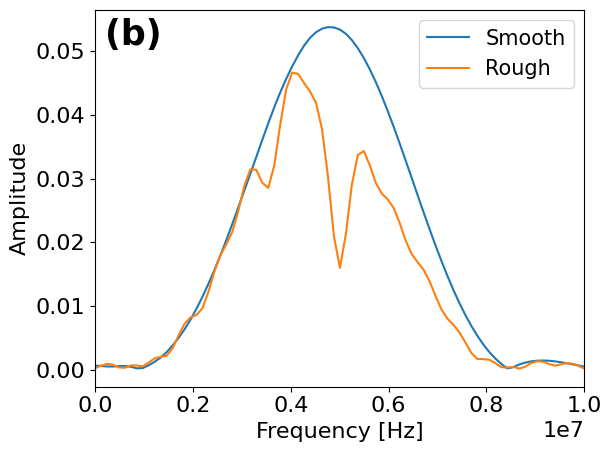

In [ ]:
plt.figure()
plt.plot(freq, yf_sim_ref, label="Smooth")
plt.plot(freq, yf_sim_rough, label="Rough")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Amplitude")
plt.legend(fontsize=15, loc="upper right")
# 左上に (a) を追加
plt.text(0.02, 0.98, "(b)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
plt.xlim(0, 10e6)
plt.tight_layout()
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure7b.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


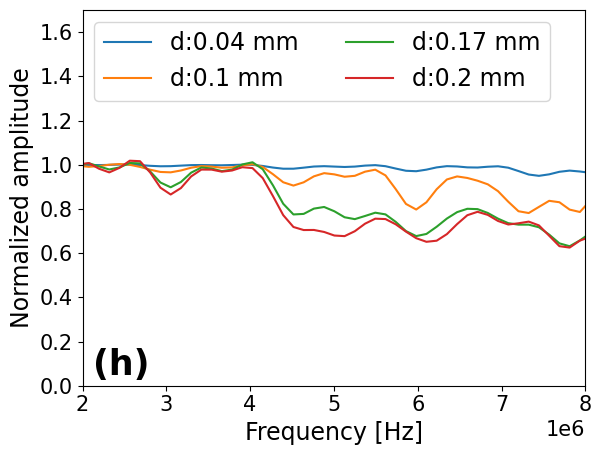

In [ ]:
def select_pitch_and_image(pitch, depth_list):
    sim_data_ref = np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth0.csv")
    yf_ref, freq_ref = sourse_new.make_fftdata(
        sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_data_ref)[8000:], sourse_new.left, sourse_new.right),
        sourse_new.exp_dt,
    )

    sim_data = np.zeros((len(depth_list), len(sim_data_ref)))
    yf = np.zeros((len(depth_list), len(yf_ref)))
    freq = np.zeros((len(depth_list), len(freq_ref)))

    for i in range(len(depth_list)):
        sim_data[i] = np.loadtxt(f"C:\\Users\\manat\\project2\\data_all\\cupy_pitch{pitch}_depth{depth_list[i]}.csv")
        yf[i], freq[i] = sourse_new.make_fftdata(
            sourse_new.kiritori2(sourse_new.interpolate_sim_one(sim_data[i])[8000:], sourse_new.left, sourse_new.right),
            sourse_new.exp_dt,
        )

    plt.rcParams["font.size"] = 15
    plt.figure()
    for i in range(len(depth_list)):
        plt.plot(freq_ref, yf[i] / yf_ref, label=f"d:{int(depth_list[i]) / 100} mm")

    # 左上に (a) を追加
    plt.text(0.02, 0.1, "(h)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
    plt.xlim(2000000, 8000000)
    plt.ylim(0, 1.7)
    plt.ylabel("Normalized amplitude", fontsize=17)
    plt.xlabel("Frequency [Hz]", fontsize=17)
    plt.legend(ncol=2, loc="upper left", fontsize=17)
    plt.tight_layout()
    plt.savefig(rf"C:\Users\manat\project2\drawing\jasa\Figure8h.eps", format="eps", dpi=300)
    plt.show()


select_pitch_and_image(200, [4, 10, 17, 20])

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_50.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_51.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_52.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


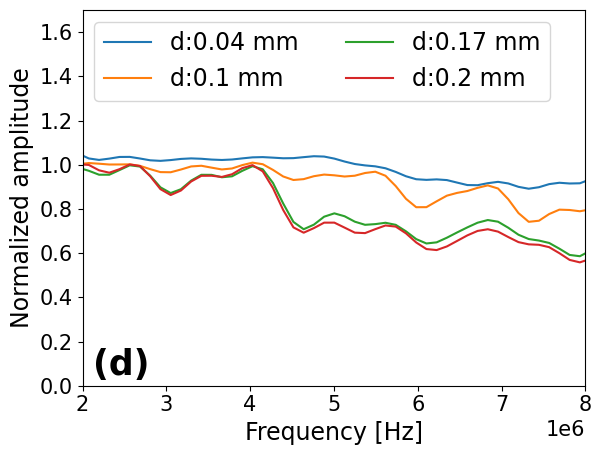

In [ ]:
def select_pitch_and_image_exp(pitch, depth_list):
    sim_data_ref, gomi = sourse_new.import_data(0, 0)
    yf_ref, freq_ref = sourse_new.make_fftdata(
        sourse_new.kiritori2(sim_data_ref, sourse_new.left, sourse_new.right), sourse_new.exp_dt
    )

    sim_data = np.zeros((len(depth_list), len(sim_data_ref)))
    yf = np.zeros((len(depth_list), len(yf_ref)))
    freq = np.zeros((len(depth_list), len(freq_ref)))

    for i in range(len(depth_list)):
        sim_data[i], gomi = sourse_new.import_data(pitch, depth_list[i])
        yf[i], freq[i] = sourse_new.make_fftdata(
            sourse_new.kiritori2(sim_data[i], sourse_new.left, sourse_new.right), sourse_new.exp_dt
        )

    plt.rcParams["font.size"] = 15
    plt.figure()
    for i in range(len(depth_list)):
        plt.plot(freq_ref, yf[i] / yf_ref, label=f"d:{depth_list[i] / 100} mm")

    # 左上に (a) を追加
    plt.text(0.02, 0.1, "(d)", transform=plt.gca().transAxes, fontsize=25, weight="bold", ha="left", va="top")
    plt.xlim(2000000, 8000000)
    plt.ylim(0, 1.7)
    plt.ylabel("Normalized amplitude", fontsize=17)
    plt.xlabel("Frequency [Hz]", fontsize=17)
    plt.legend(ncol=2, loc="upper left", fontsize=17)
    plt.tight_layout()
    plt.savefig(rf"C:\Users\manat\project2\drawing\jasa\Figure8d.eps", format="eps", dpi=300)
    plt.show()


select_pitch_and_image_exp(200, [4, 10, 17, 20])

In [ ]:
wave1_20 = sourse_new.import_data(125, 20)[0]
wave2_20 = sourse_new.import_data(200, 20)[0]
yf1_20, freq = sourse_new.make_fftdata_main_tale(
    sourse_new.kiritori2(
        sourse_new.interpolate_sim_one(-np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch125_depth20.csv")[9000:]),
        sourse_new.left,
        sourse_new.right,
    ),
    sourse_new.exp_dt,
    1550,
)
yf2_20, freq = sourse_new.make_fftdata_main_tale(
    sourse_new.kiritori2(
        sourse_new.interpolate_sim_one(-np.loadtxt(r"C:\Users\manat\project2\data_all\cupy_pitch200_depth20.csv")[9000:]),
        sourse_new.left,
        sourse_new.right,
    ),
    sourse_new.exp_dt,
    1550,
)

filename_1_20 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_125_moredepth.npy"
filename_2_20 = f"C:\\Users\\manat\\project2\\surface_wave_2d\\T3\\T3_series_middle_moremorerange_moredepth.npy"

importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_50.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_51.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_52.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_53.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_54.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_55.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_56.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_57.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_58.csv
importing : C:\Users\manat\project2\experience_new\125_20\scope_5b1_59.csv
importing : C:\Users\manat\project2\experience_new\200_20\scope_5b1_100.csv
importing : C:\Users\manat\project2\experience_new\200_20\scope_5b1_101.csv
importing : C:\Users\manat\project2\experience_new\200_20\scope_5b1_102.csv
importing : C:\Users\m

C:\Users\manat\AppData\Local\Temp\ipykernel_18616\1392911489.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{tick/1e6:.0f}' for tick in ticks])
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


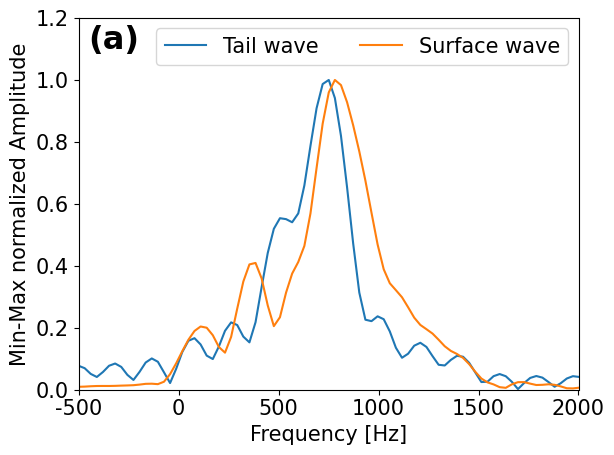

In [ ]:
middle_125 = int(250)
middle_200 = int((1799 + 1975) / 2 - 1750)

data1 = np.load(filename_1_20)
data2 = np.load(filename_2_20)

yf_surface_1, freq_surface = sourse_new.make_fftdata(
    sourse_new.kiritori2(sourse_new.interpolate_sim_one(data1[-1, middle_125, :]), sourse_new.left, sourse_new.right),
    sourse_new.exp_dt,
)

plt.rcParams["font.size"] = 15
plt.plot(freq[0], yf1_20[2] / yf1_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_1 / yf_surface_1.max(), label="Surface wave")

plt.xlim(0, 10000000)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")
# 左上に (a) を追加
plt.text(0.02, 0.98, "(a)", transform=plt.gca().transAxes, fontsize=23, weight="bold", ha="left", va="top")
plt.tight_layout()
plt.legend(loc="upper right", ncol=2)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure11a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


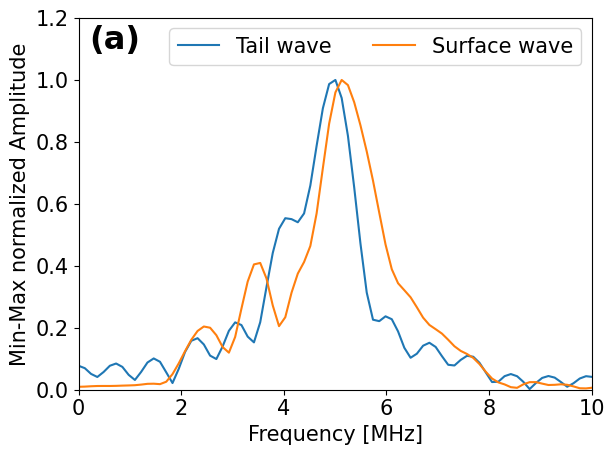

In [ ]:
middle_125 = int(250)
middle_200 = int((1799 + 1975) / 2 - 1750)

data1 = np.load(filename_1_20)
data2 = np.load(filename_2_20)

yf_surface_1, freq_surface = sourse_new.make_fftdata(
    sourse_new.kiritori2(sourse_new.interpolate_sim_one(data1[-1, middle_125, :]), sourse_new.left, sourse_new.right),
    sourse_new.exp_dt,
)

plt.rcParams["font.size"] = 15
# 周波数を1e6で割って表示
plt.plot(freq[0] / 1e6, yf1_20[2] / yf1_20[2].max(), label="Tail wave")
plt.plot(freq_surface / 1e6, yf_surface_1 / yf_surface_1.max(), label="Surface wave")

plt.xlim(0, 10)  # 0〜10に変更
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [MHz]")  # または "Frequency (×10⁶ Hz)"
# 左上に (a) を追加
plt.text(0.02, 0.98, "(a)", transform=plt.gca().transAxes, fontsize=23, weight="bold", ha="left", va="top")
plt.tight_layout()
plt.legend(loc="upper right", ncol=2)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure11a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


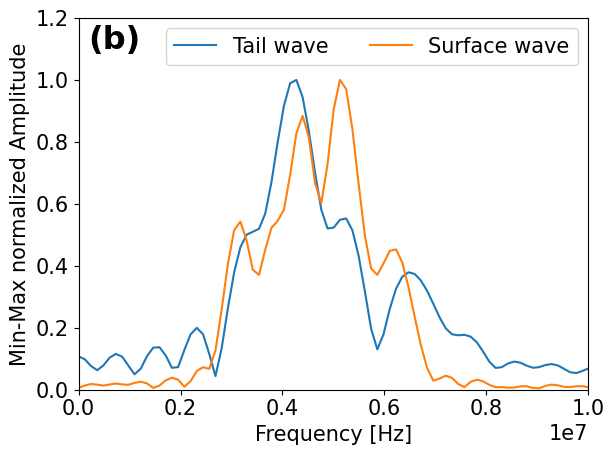

In [ ]:
yf_surface_2, freq_surface = sourse_new.make_fftdata(
    sourse_new.kiritori2(sourse_new.interpolate_sim_one(data2[-1, middle_200, :]), sourse_new.left, sourse_new.right),
    sourse_new.exp_dt,
)

plt.rcParams["font.size"] = 15
plt.plot(freq[0], yf2_20[2] / yf2_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_2 / yf_surface_2.max(), label="Surface wave")

plt.xlim(0, 1e7)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")
# 左上に (a) を追加
plt.text(0.02, 0.98, "(b)", transform=plt.gca().transAxes, fontsize=23, weight="bold", ha="left", va="top")
plt.tight_layout()
plt.legend(loc="upper right", ncol=2)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure11b.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


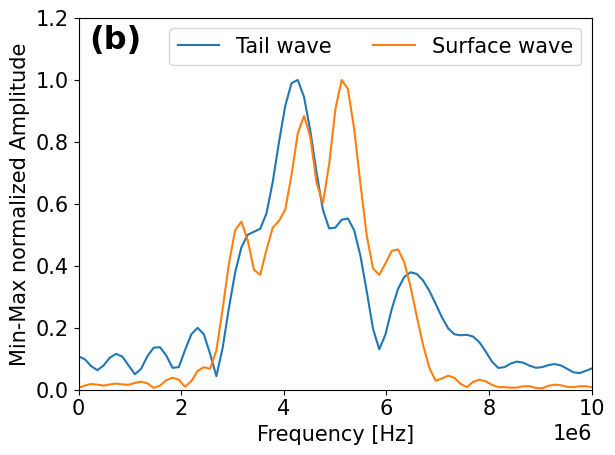

In [ ]:
yf_surface_2, freq_surface = sourse_new.make_fftdata(
    sourse_new.kiritori2(sourse_new.interpolate_sim_one(data2[-1, middle_200, :]), sourse_new.left, sourse_new.right),
    sourse_new.exp_dt,
)

plt.rcParams["font.size"] = 15
plt.plot(freq[0], yf2_20[2] / yf2_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_2 / yf_surface_2.max(), label="Surface wave")

plt.xlim(0, 1e7)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")

# 横軸に×10⁶を表示（右下に1e6が表示される）
plt.ticklabel_format(axis="x", style="sci", scilimits=(6, 6))

# 左上に (b) を追加
plt.text(0.02, 0.98, "(b)", transform=plt.gca().transAxes, fontsize=23, weight="bold", ha="left", va="top")
plt.tight_layout()
plt.legend(loc="upper right", ncol=2)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure11b.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


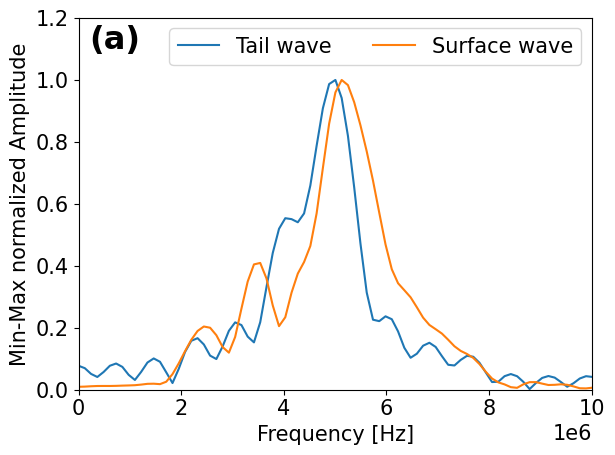

In [ ]:
middle_125 = int(250)
middle_200 = int((1799 + 1975) / 2 - 1750)

data1 = np.load(filename_1_20)
data2 = np.load(filename_2_20)

yf_surface_1, freq_surface = sourse_new.make_fftdata(
    sourse_new.kiritori2(sourse_new.interpolate_sim_one(data1[-1, middle_125, :]), sourse_new.left, sourse_new.right),
    sourse_new.exp_dt,
)

plt.rcParams["font.size"] = 15
# データはそのまま（割らない）
plt.plot(freq[0], yf1_20[2] / yf1_20[2].max(), label="Tail wave")
plt.plot(freq_surface, yf_surface_1 / yf_surface_1.max(), label="Surface wave")

plt.xlim(0, 10000000)
plt.ylim(0, 1.2)
plt.ylabel("Min-Max normalized Amplitude")
plt.xlabel("Frequency [Hz]")

# 横軸に×10⁶を表示（右下に1e6が表示される）
plt.ticklabel_format(axis="x", style="sci", scilimits=(6, 6))

# 左上に (a) を追加
plt.text(0.02, 0.98, "(a)", transform=plt.gca().transAxes, fontsize=23, weight="bold", ha="left", va="top")
plt.tight_layout()
plt.legend(loc="upper right", ncol=2)
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure11a.eps", format="eps", dpi=300)
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


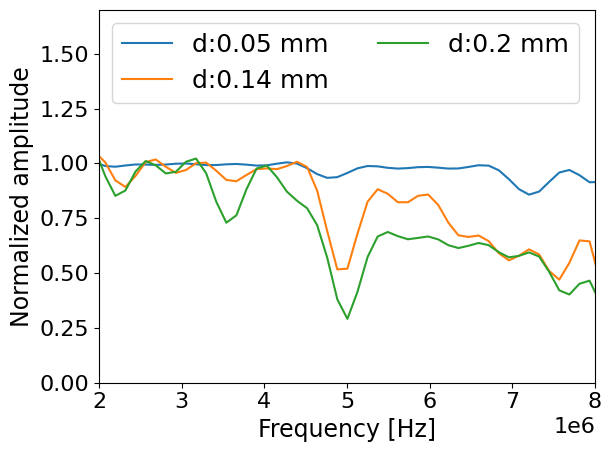

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


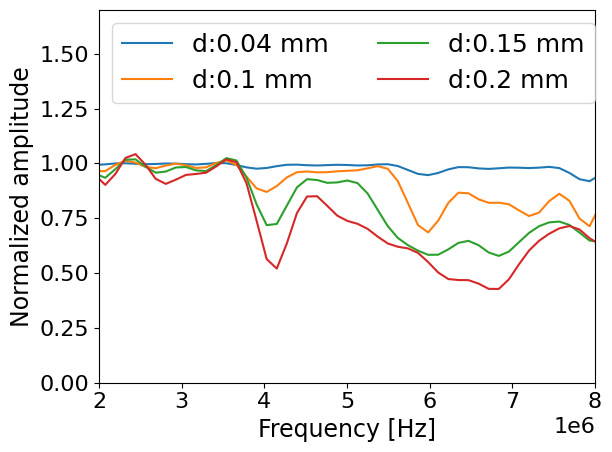

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


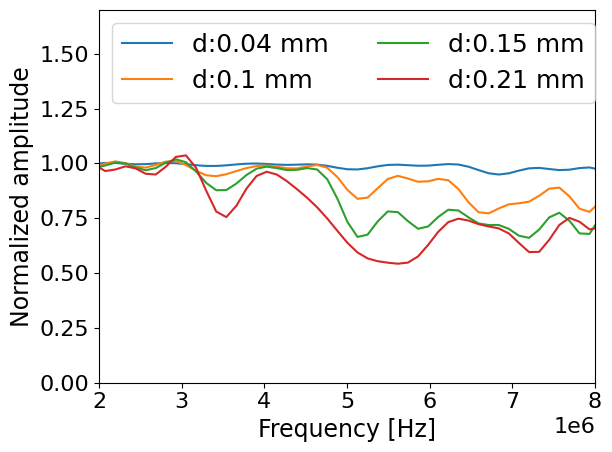

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


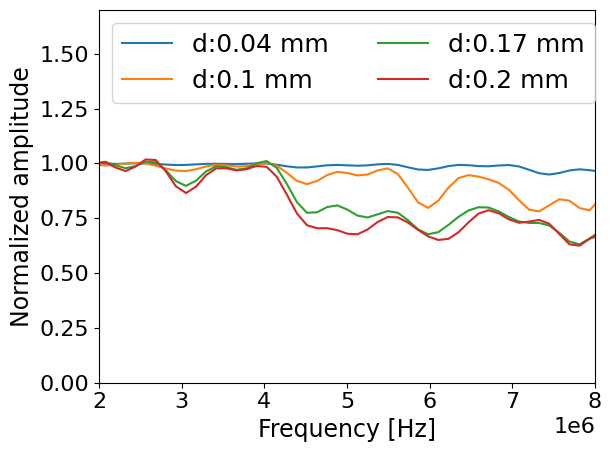

In [19]:
sourse_new.select_pitch_and_image(125, [5, 14, 20])
sourse_new.select_pitch_and_image(150, [4, 10, 15, 20])
sourse_new.select_pitch_and_image(175, [4, 10, 15, 21])
sourse_new.select_pitch_and_image(200, [4, 10, 17, 20])

In [ ]:
depth_list = [0, 40, 100, 170, 200]
surface_wave = np.zeros((6, 4096))
for i in range(len(depth_list)):
    surface_wave[i] = sourse_new.interpolate_sim_one(
        np.load(rf"C:\Users\manat\project2\surface_wave_2d\T3\T3_series_middle_point_pitch_200_depth{depth_list[i]}.npy")
    )[982 : 982 + 4096]
    surface_wave[i] = -surface_wave[i]

In [ ]:
exp_wave = np.zeros((6, 20000))
for i in range(len(depth_list)):
    if i == 0:
        exp_wave[i] = sourse_new.import_data(0, 0)[0]
    else:
        exp_wave[i] = sourse_new.import_data(200, int(depth_list[i] / 10))[0]

importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_0.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_1.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_2.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_3.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_4.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_5.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_6.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_7.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_8.csv
importing : C:\Users\manat\project2\experience_new\0_0\scope_5b1_9.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_50.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_51.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_52.csv
importing : C:\Users\manat\project2\experience_new\200_4\scope_5b3_5

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


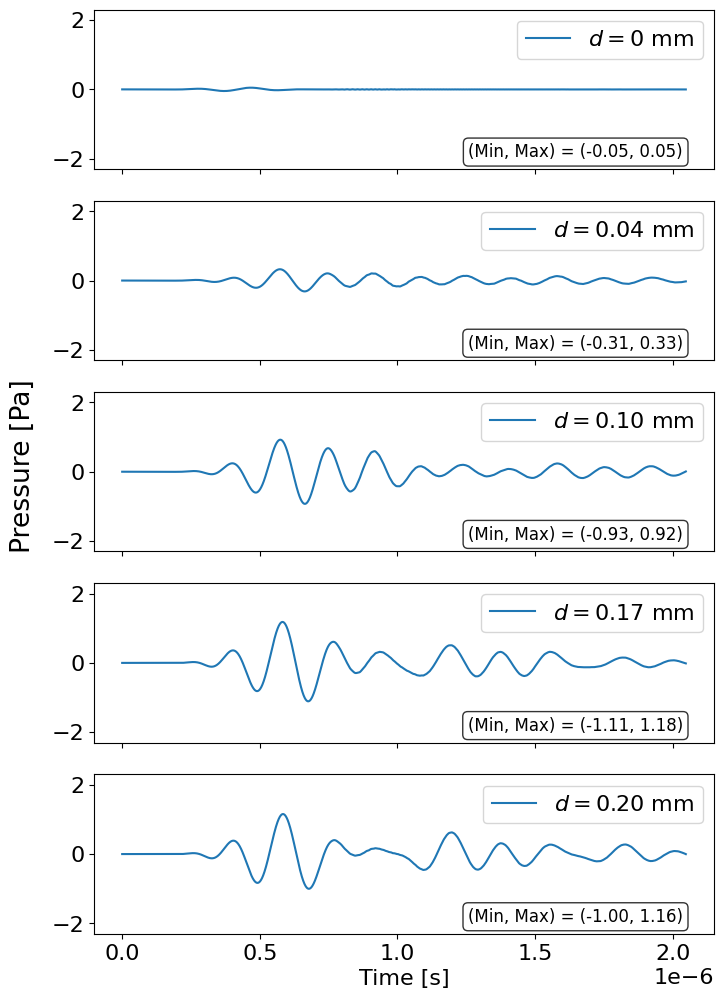

In [ ]:
plt.rcParams["font.size"] = 16
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time = np.arange(0, 4096 * sourse_new.exp_dt, sourse_new.exp_dt)
labels = ["$d=0$ mm", "$d=0.04$ mm", "$d=0.10$ mm", "$d=0.17$ mm", "$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(surface_wave[i])
    max_val = np.max(surface_wave[i])
    axes[i].plot(time, surface_wave[i], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-2.3, 2.3)
    # 右下に最大値と最小値を表示
    axes[i].text(
        0.95,
        0.05,
        f"(Min, Max) = ({min_val:.2f}, {max_val:.2f})",
        transform=axes[i].transAxes,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        fontsize=12,
    )


plt.xlabel("Time [s]")
fig.supylabel("Pressure [Pa]")
plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure12b.eps", format="eps")

# グラフを表示
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


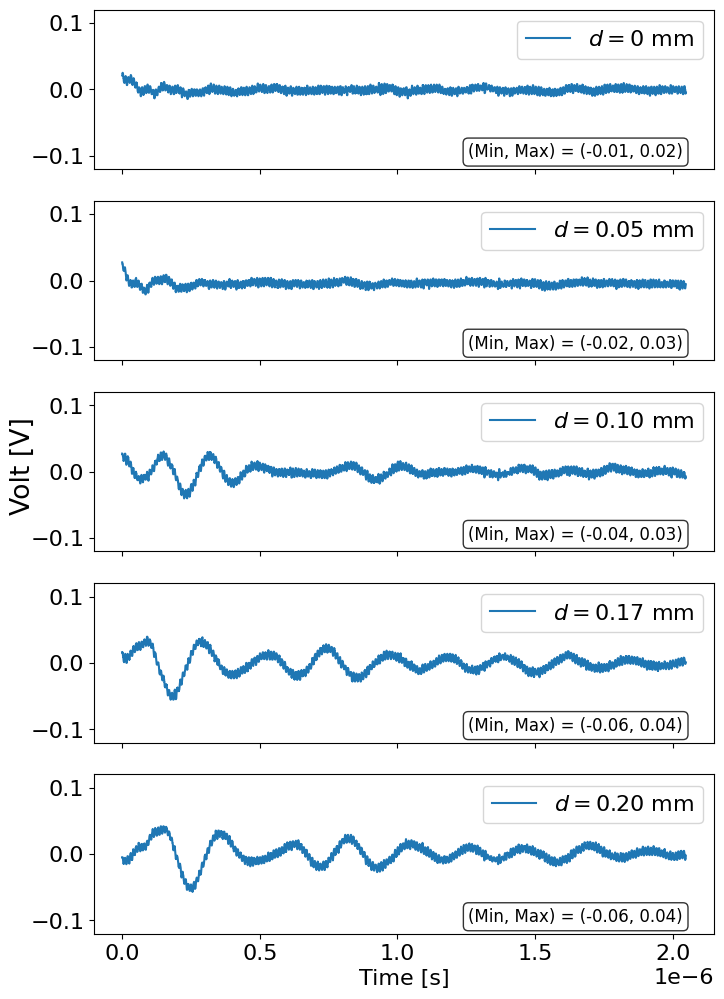

In [ ]:
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(8, 12))
time_exp = np.arange(
    0, len(exp_wave[0][1800 + sourse_new.left : 4096 + 1800 + sourse_new.left]) * sourse_new.exp_dt, sourse_new.exp_dt
)
labels = ["$d=0$ mm", "$d=0.05$ mm", "$d=0.10$ mm", "$d=0.17$ mm", "$d=0.20$ mm"]

for i in range(5):
    # 最大値と最小値を計算
    min_val = np.min(exp_wave[i][1800 + sourse_new.left : 4096 + 1800 + sourse_new.left])
    max_val = np.max(exp_wave[i][1800 + sourse_new.left : 4096 + 1800 + sourse_new.left])
    axes[i].plot(time_exp, exp_wave[i][1800 + sourse_new.left : 4096 + 1800 + sourse_new.left], label=labels[i])
    axes[i].legend()
    axes[i].set_ylim(-0.12, 0.12)
    # 右下に最大値と最小値を表示
    axes[i].text(
        0.95,
        0.05,
        f"(Min, Max) = ({min_val:.2f}, {max_val:.2f})",
        transform=axes[i].transAxes,
        verticalalignment="bottom",
        horizontalalignment="right",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
        fontsize=12,
    )


plt.xlabel("Time [s]")
fig.supylabel("Volt [V]")

plt.savefig(r"C:\Users\manat\project2\drawing\jasa\Figure12a.eps", format="eps")

# グラフを表示
plt.show()